In [ ]:
#importujemy niezbędne biblioteki, pandas (przetwarzanie danych), matplotlib (wizualizacja), sklearn (uczenie maszynowe)
#celem projektu jest analiza danych dot. czynników wpływających na stres. będziemy używać regresji wykorzystując random forest
#model będziemy oceniać na podstawie miernika r2 oraz feature importance przedstawionych na wykresach

import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import r2_score

In [ ]:
#zaczytujemy plik z danymi
df = pd.read_csv("stress.csv")
df.head()

,user_id,age,gender,occupation,daily_screen_time_hours,phone_usage_before_sleep_minutes,sleep_duration_hours,sleep_quality_score,stress_level,caffeine_intake_cups,physical_activity_minutes,notifications_received_per_day,mental_fatigue_score
0,1,56,Female,Designer,3.26,86,5.31,7.72,3.49,0,35,119,3.57
1,2,46,Female,Teacher,1.85,32,7.36,9.70,3.01,0,16,299,1.91
2,3,32,Female,Designer,3.04,107,4.50,6.38,5.03,0,17,21,6.05
3,4,25,Male,Software Engineer,9.00,36,6.68,5.53,10.00,0,3,220,9.92
4,5,38,Female,Teacher,3.52,56,7.57,6.69,6.71,4,92,167,5.99


In [ ]:
#sprawdzamy zawartość pliku (typ danych i podstawowe mierniki)
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 13 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   user_id                           15000 non-null  int64  
 1   age                               15000 non-null  int64  
 2   gender                            15000 non-null  object 
 3   occupation                        15000 non-null  object 
 4   daily_screen_time_hours           15000 non-null  float64
 5   phone_usage_before_sleep_minutes  15000 non-null  int64  
 6   sleep_duration_hours              15000 non-null  float64
 7   sleep_quality_score               15000 non-null  float64
 8   stress_level                      15000 non-null  float64
 9   caffeine_intake_cups              15000 non-null  int64  
 10  physical_activity_minutes         15000 non-null  int64  
 11  notifications_received_per_day    15000 non-null  int64  
 12  ment

,user_id,age,daily_screen_time_hours,phone_usage_before_sleep_minutes,sleep_duration_hours,sleep_quality_score,stress_level,caffeine_intake_cups,physical_activity_minutes,notifications_received_per_day,mental_fatigue_score
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.00000,15000.000000,15000.000000,15000.000000
mean,7500.500000,38.488467,5.501528,59.708933,6.509683,6.246362,6.980247,1.99880,59.157133,160.890467,6.873009
std,4330.271354,12.007970,2.600085,34.641858,1.452689,1.713644,2.749382,1.41459,34.525705,80.856902,2.730482
min,1.000000,18.000000,1.000000,0.000000,4.000000,1.000000,1.000000,0.00000,0.000000,20.000000,1.000000
25%,3750.750000,28.000000,3.260000,29.000000,5.260000,5.000000,4.750000,1.00000,29.000000,92.000000,4.700000
50%,7500.500000,38.000000,5.490000,60.000000,6.490000,6.250000,7.380000,2.00000,59.000000,162.000000,7.380000
75%,11250.250000,49.000000,7.760000,90.000000,7.790000,7.500000,10.000000,3.00000,89.000000,231.000000,9.450000
max,15000.000000,59.000000,10.000000,119.000000,9.000000,10.000000,10.000000,4.00000,119.000000,299.000000,10.000000


In [ ]:
#kodujemy zmienne opisowe (typu object, tutaj: gender)
le = LabelEncoder()
df["gender_encoded"] = le.fit_transform(df["gender"])
df[["gender_encoded", 'gender']].drop_duplicates()

,gender_encoded,gender
0,0,Female
3,1,Male
33,2,Other


In [ ]:
#kodujemy zmienne opisowe (typu object, tutaj: occupation)
df["occup_encoded"] = le.fit_transform(df["occupation"])
df[["occup_encoded", 'occupation']].drop_duplicates().sort_values(by="occup_encoded")

,occup_encoded,occupation
0,0,Designer
20,1,Doctor
16,2,Freelancer
7,3,Manager
23,4,Researcher
3,5,Software Engineer
8,6,Student
1,7,Teacher


In [ ]:
#usuwamy niepotrzebne kolumny gender i occupation (sprzed kodowania - mamy je w dodanych kolumnach typu int) oraz user id (zbędne)
df = df.drop(["gender", "occupation", "user_id"], axis=1)
df

,age,daily_screen_time_hours,phone_usage_before_sleep_minutes,sleep_duration_hours,sleep_quality_score,stress_level,caffeine_intake_cups,physical_activity_minutes,notifications_received_per_day,mental_fatigue_score,gender_encoded,occup_encoded
0,56,3.26,86,5.31,7.72,3.49,0,35,119,3.57,0,0
1,46,1.85,32,7.36,9.70,3.01,0,16,299,1.91,0,7
2,32,3.04,107,4.50,6.38,5.03,0,17,21,6.05,0,0
3,25,9.00,36,6.68,5.53,10.00,0,3,220,9.92,1,5
4,38,3.52,56,7.57,6.69,6.71,4,92,167,5.99,0,7
...,...,...,...,...,...,...,...,...,...,...,...,...
14995,39,8.05,45,8.91,4.33,10.00,1,40,259,10.00,1,3
14996,22,6.44,80,6.00,5.22,10.00,2,41,231,7.54,0,6
14997,51,7.01,78,7.27,5.37,8.66,4,93,288,7.78,0,5
14998,56,7.89,6,5.70,5.71,9.56,1,91,47,9.98,0,5


In [ ]:
#dzielimy na analizowane i przewidywane
X = df.drop("stress_level", axis=1)
y = df["stress_level"]

In [ ]:
#dzielimy na zbiory: treningowy i testowy
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
#trenujemy model i używamy go do przewidzenia wartości (stress_level)
model_rf = RandomForestRegressor(n_estimators=100, random_state=42)

model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)

In [ ]:
#wyświetlamy wynik miernika r2, posiłkując się interpretacją z: https://www.cognity.pl/rmse-mae-r2-accuracy-precision-recall-jak-dobrac-metryke
#oceniamy, że wynik jest bardzo dobry (bliskość do 1)
r2 = r2_score(y_test, y_pred_rf)
print(f"R2: {r2:.3f}")

R2: 0.948


In [ ]:
#mierzymy feature importance
#uzyskany mocno dominujący wynik dla wskaźnika mental_fatigue_score skłania ku ponownej analizie z wyłączeniem tego wskaźnika
#mental fatigue intuicyjnie wydaje się bardzo pokrewne ze stress level
importance = model_rf.feature_importances_

feature_importance = pd.Series(importance, index=X.columns)
feature_importance = feature_importance.sort_values(ascending=False)

print(feature_importance)

mental_fatigue_score                0.895670
daily_screen_time_hours             0.041747
sleep_quality_score                 0.033155
notifications_received_per_day      0.005191
sleep_duration_hours                0.005005
physical_activity_minutes           0.004858
phone_usage_before_sleep_minutes    0.004821
age                                 0.004388
occup_encoded                       0.002499
caffeine_intake_cups                0.001811
gender_encoded                      0.000856
dtype: float64


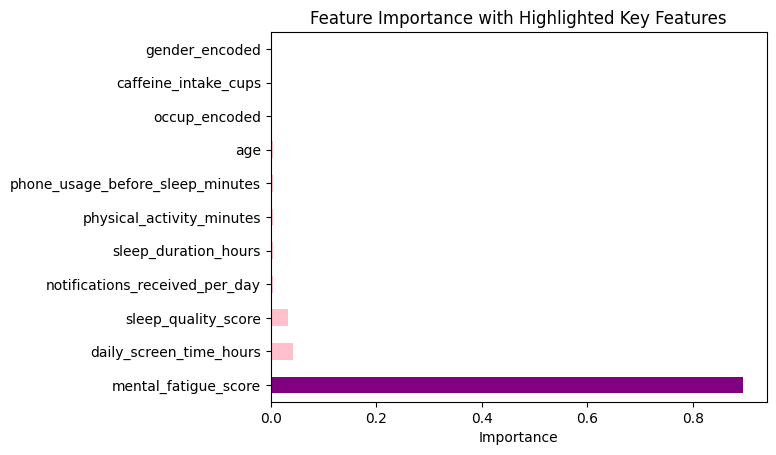

In [ ]:
#rysujemy wykres dla uzyskanych wartości
feature_names = X.columns
colors = []

for val in feature_importance:
    if val > 0.2:
        colors.append("purple")
    else:
        colors.append("pink")

feature_importance.plot(kind="barh", color=colors)
plt.xlabel("Importance")
plt.title("Feature Importance with Highlighted Key Features")
plt.show()

In [ ]:
#dzielimy na analizowane i przewidywane; usuwamy kolumnę (wskaźnik) mental_fatigue_score
X = df.drop(["stress_level", "mental_fatigue_score"], axis=1)
y = df["stress_level"]

In [ ]:
#ponownie dzielimy na zbiory: treningowy i testowy
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
#ponownie trenujemy model i używamy go do przewidzenia wartości (stress_level) z wyłączeniem mental_fatigue_score
model_rf = RandomForestRegressor(n_estimators=100, random_state=42)

model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)

In [ ]:
#wyświetlamy wynik miernika r2
#jest o kilka punktów niższy, co wydaje się zasadne z uwagi na usunięcie ogromnego predykatu z modelu
r2 = r2_score(y_test, y_pred_rf)
print(f"R2: {r2:.3f}")

R2: 0.897


In [ ]:
#mierzymy feature importance
#dzięki usunięciu mental_fatigue_score możemy zauważyć duże znaczenie dwóch wskaźników: daily_screen_time_hours oraz sleep_quality_score
importance = model_rf.feature_importances_

feature_importance = pd.Series(importance, index=X.columns)
feature_importance = feature_importance.sort_values(ascending=False)

print(feature_importance)

daily_screen_time_hours             0.709939
sleep_quality_score                 0.222899
notifications_received_per_day      0.012069
sleep_duration_hours                0.011993
physical_activity_minutes           0.011089
phone_usage_before_sleep_minutes    0.010694
age                                 0.009460
occup_encoded                       0.005697
caffeine_intake_cups                0.004053
gender_encoded                      0.002107
dtype: float64


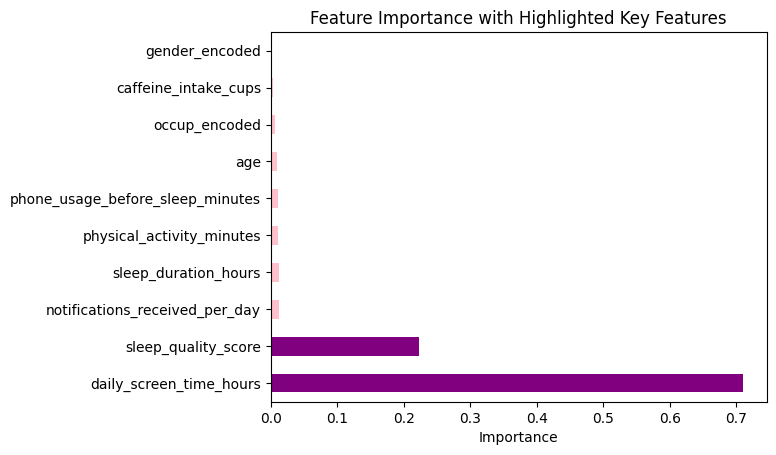

In [ ]:
#rysujemy wykres dla uzyskanych wartości
feature_names = X.columns
colors = []

for val in feature_importance:
    if val > 0.2:
        colors.append("purple")
    else:
        colors.append("pink")

feature_importance.plot(kind="barh", color=colors)
plt.xlabel("Importance")
plt.title("Feature Importance with Highlighted Key Features")
plt.show()